# Notebook 06 — XAI / Explicabilidade (Modelo 1: Aplicação)

Análise SHAP da Regressão Logística final. Carrega o pipeline treinado e o
hold-out salvos no notebook 05. Como o modelo é linear, usamos `LinearExplainer`
(SHAP values exatos, proporcionais a coeficiente × valor da feature).

In [ ]:
!pip install shap -q

import numpy as np
import pandas as pd
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.base import BaseEstimator, TransformerMixin

SEED = 42
MODEL_PATH = "/content/drive/MyDrive/ML_Inadimplencia_Praso/models"

# AgrupaRaras precisa estar definida para o joblib reconstruir o pipeline salvo
# (mesma definicao usada no notebook 05)
class AgrupaRaras(BaseEstimator, TransformerMixin):
    """Agrupa categorias com frequencia < threshold no treino em '__rara__'."""
    def __init__(self, threshold=0.05):
        self.threshold = threshold

    def fit(self, X, y=None):
        X_arr = X.values if hasattr(X, "values") else X
        self.categorias_freq_ = {}
        for col in range(X_arr.shape[1]):
            serie = pd.Series(X_arr[:, col])
            freq  = serie.value_counts(normalize=True)
            self.categorias_freq_[col] = set(freq[freq >= self.threshold].index)
        return self

    def transform(self, X):
        X_arr = (X.values if hasattr(X, "values") else X).copy().astype(object)
        for col in range(X_arr.shape[1]):
            mask = ~pd.Series(X_arr[:, col]).isin(self.categorias_freq_[col])
            X_arr[mask, col] = "__rara__"
        return X_arr

# Carrega pipeline treinado + hold-out
model  = joblib.load(f"{MODEL_PATH}/modelo_aplicacao_lr.joblib")
X_test = pd.read_parquet(f"{MODEL_PATH}/aplicacao_X_test.parquet")
y_test = pd.read_parquet(f"{MODEL_PATH}/aplicacao_y_test.parquet")["inadimplente"]

with open(f"{MODEL_PATH}/aplicacao_threshold.json") as f:
    thr_final = json.load(f)["threshold"]

print(f"Pipeline carregado: {[n for n, _ in model.steps]}")
print(f"X_test : {X_test.shape}")
print(f"y_test : {y_test.shape} | inadimplencia: {y_test.mean():.1%}")
print(f"Threshold final: {thr_final}")

Pipeline carregado: ['prep', 'model']
X_test : (600, 24)
y_test : (600,) | inadimplencia: 31.3%
Threshold final: 0.44


## Seção 1 — Preparação para SHAP

Aplicamos o preprocessor ao hold-out e reconstruímos os nomes das features
pós-transformação (numéricas + categorias expandidas pelo One-Hot Encoding),
para que os gráficos SHAP sejam legíveis.

In [ ]:
# Extrai o preprocessor e o modelo linear do pipeline
prep  = model.named_steps["prep"]
linear_model = model.named_steps["model"]

# Reconstroi os grupos de colunas a partir do ColumnTransformer ja fittado
col_groups   = {name: cols for name, trans, cols in prep.transformers_ if name != "remainder"}
num_sentinela = list(col_groups["num_sentinela"])
num_direto    = list(col_groups["num_direto"])
cat_cols      = list(col_groups["cat"])

# Transforma o hold-out (dados que o modelo realmente recebe)
X_test_prep = prep.transform(X_test)

# Nomes das features pos-OHE: o OHE foi fittado sobre array (nomes genericos x0..xN)
# Remapeamos x{i} -> nome real da coluna categorica (ordem preservada)
ohe       = prep.named_transformers_["cat"].named_steps["ohe"]
ohe_names = ohe.get_feature_names_out()
mapa_cat  = {f"x{i}": col for i, col in enumerate(cat_cols)}

ohe_legivel = []
for n in ohe_names:
    prefixo, _, valor = n.partition("_")
    ohe_legivel.append(f"{mapa_cat.get(prefixo, prefixo)}={valor}")

# Ordem do ColumnTransformer: sentinela -> direto -> cat
feat_names = num_sentinela + num_direto + ohe_legivel

print(f"X_test_prep shape : {X_test_prep.shape}")
print(f"Total de nomes    : {len(feat_names)}")
assert X_test_prep.shape[1] == len(feat_names), "Mismatch entre colunas e nomes"
print("Nomes reconstruidos com sucesso.")

X_test_prep shape : (600, 51)
Total de nomes    : 51
Nomes reconstruidos com sucesso.


## Seção 2 — Importância Global das Features

`LinearExplainer` sobre o hold-out. O beeswarm mostra magnitude e direção do
impacto de cada feature no score (log-odds); o bar plot ranqueia por importância
média absoluta.

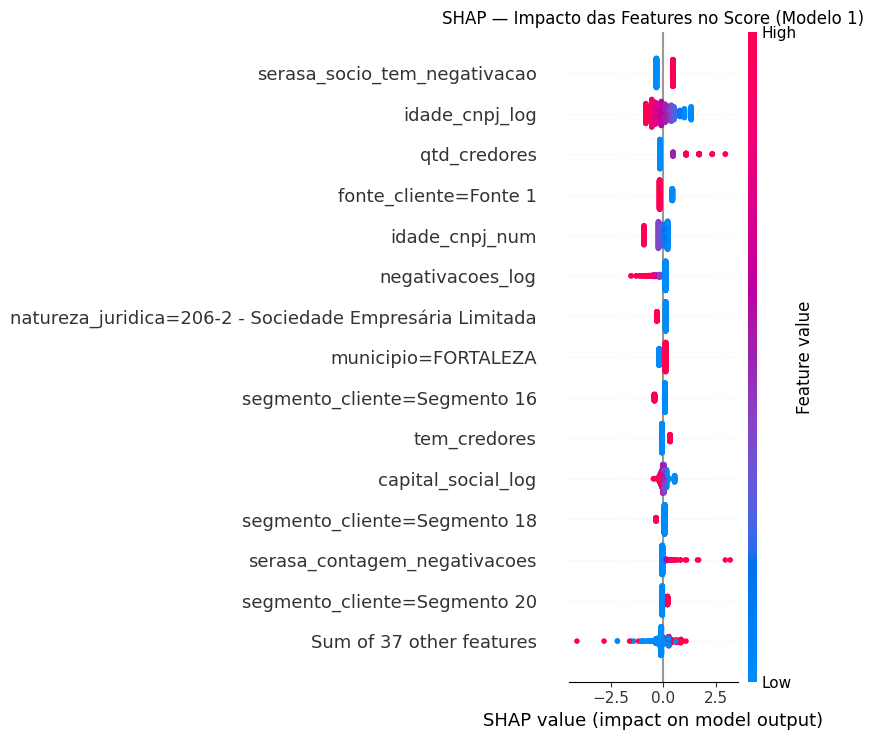

In [ ]:
# LinearExplainer: exato para modelos lineares
explainer = shap.LinearExplainer(linear_model, X_test_prep)
sv = explainer(X_test_prep)
sv.feature_names = feat_names

# Beeswarm: distribuicao do impacto por feature
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.title("SHAP — Impacto das Features no Score (Modelo 1)")
plt.tight_layout()
plt.show()

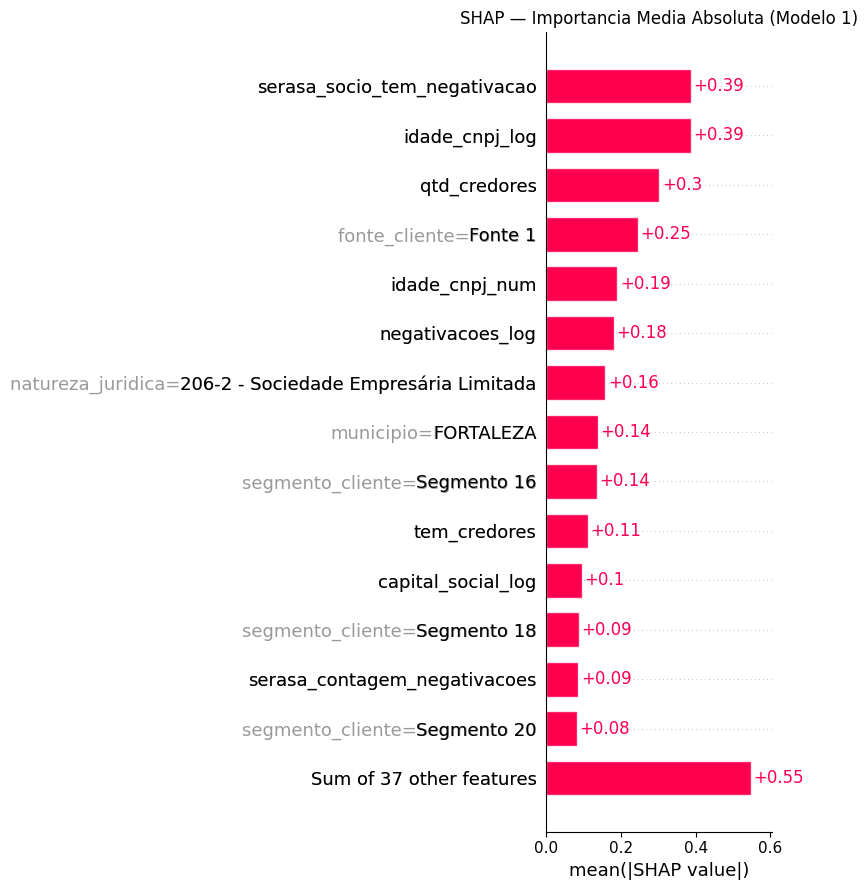

In [ ]:
# Bar plot: importancia media absoluta
shap.plots.bar(sv, max_display=15, show=False)
plt.title("SHAP — Importancia Media Absoluta (Modelo 1)")
plt.tight_layout()
plt.show()

## Seção 3 — Efeito das Top Features

Scatter plots SHAP das features mais importantes: mostram como o valor da feature
(eixo X, escala padronizada) se relaciona ao impacto no score (eixo Y).

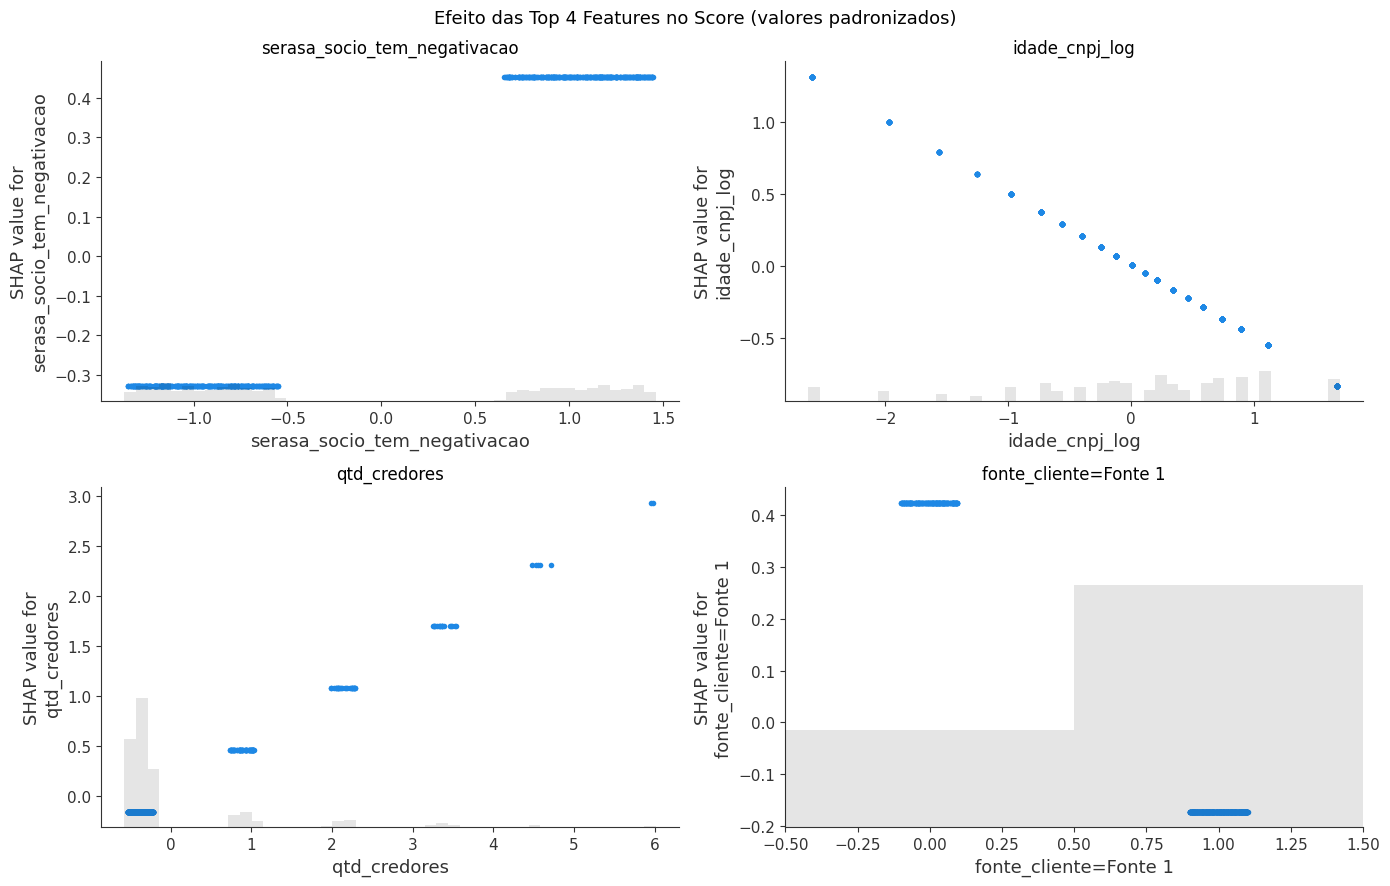

Top features por importancia SHAP:
  serasa_socio_tem_negativacao         importancia media: 0.3880
  idade_cnpj_log                       importancia media: 0.3867
  qtd_credores                         importancia media: 0.3030
  fonte_cliente=Fonte 1                importancia media: 0.2451


In [ ]:
# Identifica as top 4 features por importancia media absoluta
importancia = np.abs(sv.values).mean(axis=0)
top_idx     = np.argsort(importancia)[::-1][:4]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, idx in zip(axes.ravel(), top_idx):
    shap.plots.scatter(sv[:, idx], ax=ax, show=False)
    ax.set_title(feat_names[idx])

plt.suptitle("Efeito das Top 4 Features no Score (valores padronizados)", fontsize=13)
plt.tight_layout()
plt.show()

print("Top features por importancia SHAP:")
for idx in top_idx:
    print(f"  {feat_names[idx]:35s}  importancia media: {importancia[idx]:.4f}")

## Seção 4 — Casos Individuais (Waterfall)

Decomposição do score de dois clientes bem classificados: um adimplente de baixo
risco e um inadimplente de alto risco. Mostra como cada feature empurra o score
para cima ou para baixo a partir do valor base.

Caso ADIMPLENTE  — score=0.115 | real=0


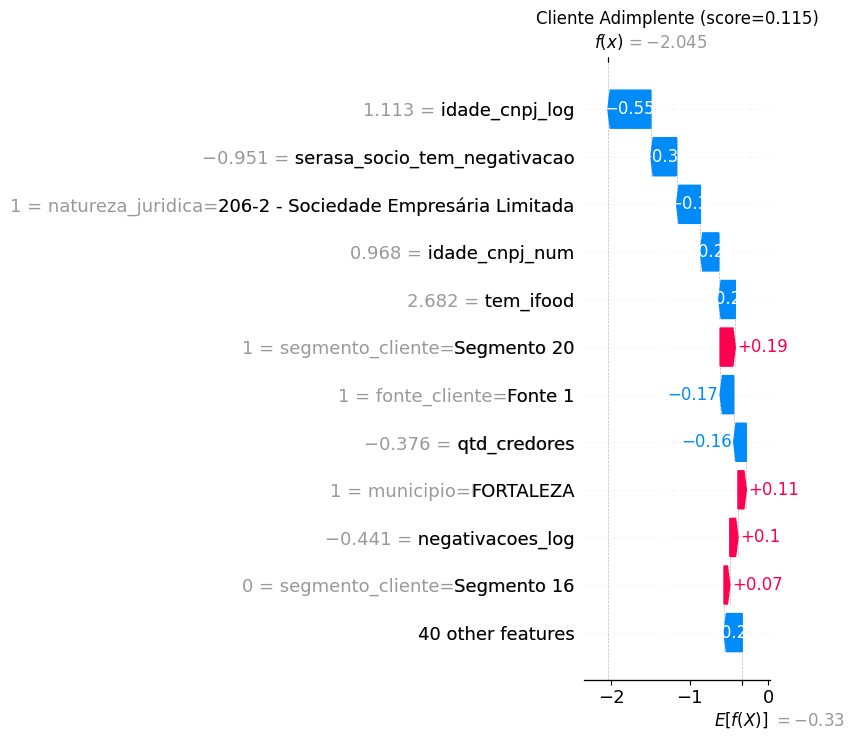

In [ ]:
y_prob = model.predict_proba(X_test)[:, 1]

# Adimplente bem classificado (score baixo, real = 0)
idx_adim = np.where((y_test.values == 0) & (y_prob < 0.15))[0][0]

# Inadimplente bem classificado (score alto, real = 1)
idx_inad = np.where((y_test.values == 1) & (y_prob > 0.80))[0][0]

print(f"Caso ADIMPLENTE  — score={y_prob[idx_adim]:.3f} | real=0")
shap.plots.waterfall(sv[idx_adim], max_display=12, show=False)
plt.title(f"Cliente Adimplente (score={y_prob[idx_adim]:.3f})")
plt.tight_layout()
plt.show()

Caso INADIMPLENTE — score=0.817 | real=1


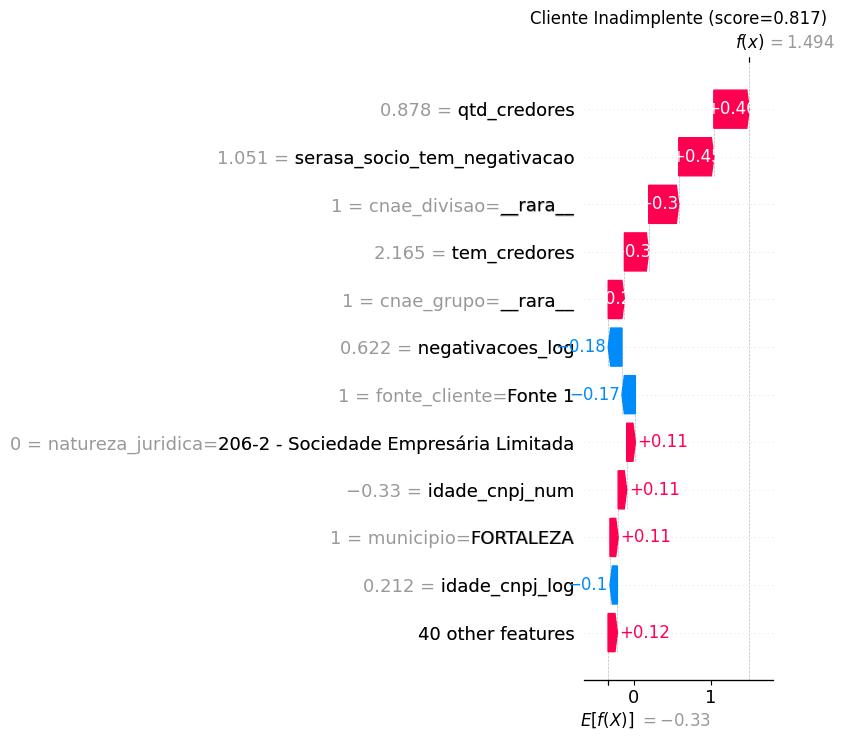

In [ ]:
print(f"Caso INADIMPLENTE — score={y_prob[idx_inad]:.3f} | real=1")
shap.plots.waterfall(sv[idx_inad], max_display=12, show=False)
plt.title(f"Cliente Inadimplente (score={y_prob[idx_inad]:.3f})")
plt.tight_layout()
plt.show()

## Seção 5 — Análise de Erros: Falsos Negativos

Os falsos negativos no threshold final (0.44) são inadimplentes que o modelo
não detectou — o erro de maior custo para a Praso. Analisamos quais features
levaram o modelo a subestimar o risco desses clientes.

In [ ]:
# Falsos negativos no threshold final: real=1, previsto=0
y_pred  = (y_prob >= thr_final).astype(int)
fn_mask = (y_pred == 0) & (y_test.values == 1)
fn_idx  = np.where(fn_mask)[0]

print(f"Falsos negativos no threshold {thr_final}: {len(fn_idx)} clientes")
print(f"Score medio dos FN: {y_prob[fn_idx].mean():.3f} (abaixo do threshold)")
print()

# Compara importancia media das features: grupo FN vs hold-out completo
shap_fn_medio    = np.abs(sv.values[fn_idx]).mean(axis=0)
shap_geral_medio = np.abs(sv.values).mean(axis=0)

comparacao = pd.DataFrame({
    "feature"   : feat_names,
    "shap_FN"   : shap_fn_medio,
    "shap_geral": shap_geral_medio,
}).assign(
    diff = lambda d: d["shap_FN"] - d["shap_geral"]
).sort_values("shap_FN", ascending=False).head(10)

print("Top features nos falsos negativos (vs media geral):")
print(comparacao.to_string(index=False, float_format="{:.4f}".format))

Falsos negativos no threshold 0.44: 45 clientes
Score medio dos FN: 0.301 (abaixo do threshold)

Top features nos falsos negativos (vs media geral):
                                                feature  shap_FN  shap_geral    diff
                           serasa_socio_tem_negativacao   0.3810      0.3880 -0.0070
                                         idade_cnpj_log   0.2756      0.3867 -0.1111
                                           qtd_credores   0.2489      0.3030 -0.0541
                                  fonte_cliente=Fonte 1   0.2010      0.2451 -0.0440
                                       negativacoes_log   0.1662      0.1817 -0.0155
natureza_juridica=206-2 - Sociedade Empresária Limitada   0.1634      0.1583  0.0051
                                         idade_cnpj_num   0.1564      0.1907 -0.0343
                           segmento_cliente=Segmento 16   0.1511      0.1365  0.0146
                                    municipio=FORTALEZA   0.1504      0.1388  0.0116
 

Falso negativo — score=0.437 | real=1 | threshold=0.44


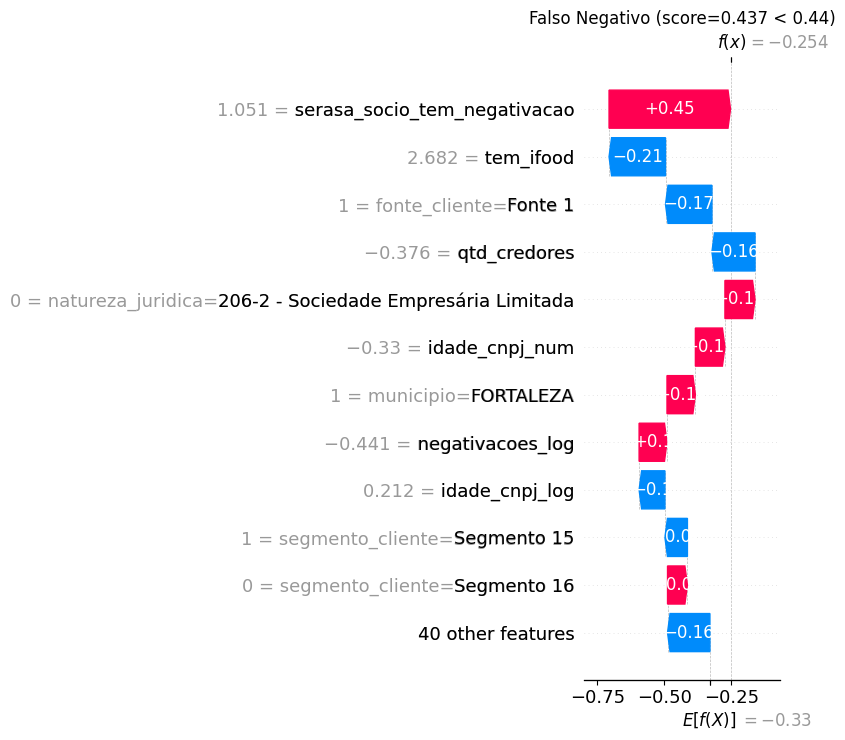

In [ ]:
# Waterfall de um falso negativo representativo (maior score entre os FN —
# o que o modelo chegou mais perto de acertar)
idx_fn = fn_idx[np.argmax(y_prob[fn_idx])]

print(f"Falso negativo — score={y_prob[idx_fn]:.3f} | real=1 | threshold={thr_final}")
shap.plots.waterfall(sv[idx_fn], max_display=12, show=False)
plt.title(f"Falso Negativo (score={y_prob[idx_fn]:.3f} < {thr_final})")
plt.tight_layout()
plt.show()

## Conclusão — XAI do Modelo de Aplicação

### Síntese da explicabilidade

A análise SHAP do modelo de aplicação confirma que a Regressão Logística aprendeu padrões coerentes com o domínio de risco de crédito, sem depender de artefatos espúrios ou vazamento de informação. As features mais influentes têm interpretação de negócio direta e clara:

- **`serasa_socio_tem_negativacao` (importância média 0.39)** é o preditor mais forte. A negativação de um sócio na Serasa empurra o score de risco fortemente para cima — alinhado à intuição de que problemas de crédito pessoais dos sócios sinalizam risco para a empresa.
- **`idade_cnpj_log` (0.39)** apresenta a relação mais limpa do modelo: monotônica decrescente. Quanto mais antigo o CNPJ, menor o risco estimado, capturando a noção de que empresas estabelecidas são mais confiáveis.
- **`qtd_credores` (0.30)** tem efeito crescente em escada: cada credor adicional eleva o score de forma consistente, refletindo o acúmulo de obrigações financeiras como fator de risco.
- **`fonte_cliente=Fonte 1` (0.25)** revela que o canal de aquisição carrega sinal preditivo — clientes da Fonte 1 apresentam risco sistematicamente menor, um insight acionável para a estratégia de aquisição da Praso.

A consistência entre a direção dos efeitos SHAP e o conhecimento de domínio é evidência de que o modelo é confiável e auditável — propriedade essencial em decisões de crédito, onde a explicabilidade não é apenas desejável, mas frequentemente uma exigência regulatória e ética.

### O valor da escolha por um modelo linear

A decisão de adotar a Regressão Logística em vez de modelos mais complexos (Random Forest, XGBoost) se mostra particularmente acertada à luz da explicabilidade. Em um modelo linear, os valores SHAP são exatos (não aproximados) e proporcionais ao produto entre coeficiente e valor da feature, o que torna cada decisão do modelo totalmente rastreável. Essa transparência, combinada ao desempenho competitivo observado na modelagem, reforça que a parcimônia foi a escolha correta para o problema — não houve trade-off entre interpretabilidade e capacidade preditiva.

### Análise de erros: o limite estrutural do Modelo de Aplicação

A investigação dos 45 falsos negativos no threshold operacional (0.44) produziu o insight mais relevante do notebook. A comparação entre a importância SHAP média nesse grupo e no conjunto completo revelou um padrão sistemático: para os falsos negativos, praticamente todas as features de risco contribuíram **menos** que a média (diferenças negativas em `idade_cnpj_log`, `qtd_credores`, `fonte_cliente` e outras).

A interpretação é direta e importante: os falsos negativos são clientes que **não exibiam sinais de alerta no perfil cadastral** — CNPJs não tão recentes, poucos credores, frequentemente sem negativação do sócio — mas que ainda assim tornaram-se inadimplentes. Em termos práticos, eram clientes que "pareciam bons no papel" no momento do cadastro.

Esse achado expõe o limite estrutural intrínseco do Modelo de Aplicação: a inadimplência que não deixa rastro nos dados cadastrais é fundamentalmente imprevisível com a informação disponível no momento do cadastro. Nenhum ajuste de hiperparâmetro ou troca de algoritmo resolveria isso, pois a limitação está nos dados, não no modelo.

### Conexão com a arquitetura de dois modelos

Esses 45 falsos negativos constituem o argumento empírico mais forte para a existência do Modelo Comportamental. O que o perfil cadastral não consegue capturar, o histórico de comportamento de pagamento captura: um cliente que parece seguro no cadastro mas começa a atrasar pagamentos é exatamente o caso que o Modelo Comportamental identifica e que o Modelo de Aplicação, por construção, não tem como prever. A análise de explicabilidade, portanto, não apenas valida o modelo atual, mas também justifica quantitativamente a estratégia de complementar a avaliação de entrada (cadastral) com o acompanhamento contínuo (comportamental) à medida que o cliente acumula histórico na plataforma.